# AutoCAD Room Extraction Experiment

This notebook builds an experimental pipeline for finding enclosed room-like regions from the captured AutoCAD image in `data/original1.png`.

The output includes:
- approximate room candidates
- four-point coordinates for each retained room
- a room count
- a green overlay drawn on the source image

The PNG currently exposes pixel size and DPI metadata. If wall lengths or outer-frame millimeter metadata are available elsewhere, those values can be joined later.

## 1. Verify Python Packages

Check whether `numpy`, `PIL`, `matplotlib`, and `cv2` are available before running the rest of the notebook.

In [1]:
import importlib.util
import site
import sys
from pathlib import Path

required_packages = {
    "numpy": "numpy",
    "PIL": "Pillow",
    "matplotlib": "matplotlib",
    "cv2": "opencv-python-headless",
}

usersite = Path(site.getusersitepackages())
if usersite.exists() and str(usersite) not in sys.path:
    sys.path.insert(0, str(usersite))

print(f"Python executable: {sys.executable}")
print(f"User site-packages: {usersite}")
print()

missing_packages = []
for module_name, package_name in required_packages.items():
    is_available = importlib.util.find_spec(module_name) is not None
    status = "OK" if is_available else "MISSING"
    print(f"{module_name:12s} -> {status}")
    if not is_available:
        missing_packages.append(package_name)

if missing_packages:
    print()
    print("Install missing packages in a notebook cell if needed:")
    print(f"%pip install {' '.join(sorted(set(missing_packages)))}")
else:
    print()
    print("All required packages are available.")

Python executable: /Users/andy/works/ai/maf-boilerplate/.venv/bin/python
User site-packages: /Users/andy/Library/Python/3.12/lib/python/site-packages

numpy        -> OK
PIL          -> OK
matplotlib   -> OK
cv2          -> OK

All required packages are available.


## 2. Load the PNG and Inspect Image Metadata

Open the floor-plan screenshot with Pillow, print the image path being used, and inspect basic PNG metadata.

In [2]:
from PIL import Image


def resolve_image_path() -> Path:
    candidates = [
        Path.cwd() / "data" / "original1.png",
        Path.cwd().parent / "data" / "original1.png",
        Path("/Users/andy/works/ai/maf-boilerplate/data/original1.png"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not find data/original1.png from the current notebook context.")


image_path = resolve_image_path()
pil_image = Image.open(image_path)
print(f"Image path: {image_path}")
print(f"Image size: {pil_image.size}")
print("PNG metadata:")
for key, value in pil_image.info.items():
    print(f"- {key}: {value}")

Image path: /Users/andy/works/ai/maf-boilerplate/data/original1.png
Image size: (905, 475)
PNG metadata:
- srgb: 0
- gamma: 0.45455
- dpi: (95.9866, 95.9866)


## 3. Display the Source Image

Render the original image inline so later masks and overlays can be compared visually.

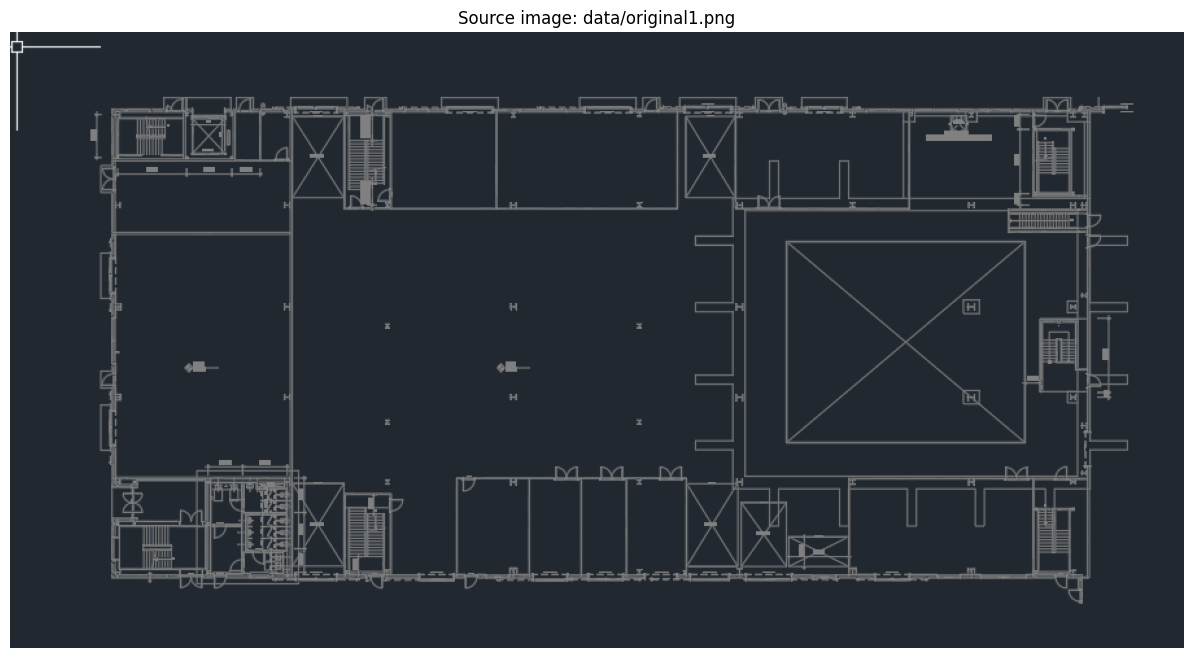

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
plt.imshow(pil_image)
plt.title("Source image: data/original1.png")
plt.axis("off")
plt.show()

## 4. Convert the Image to Grayscale

Load the PNG with OpenCV, convert BGR to grayscale, and inspect the grayscale floor plan.

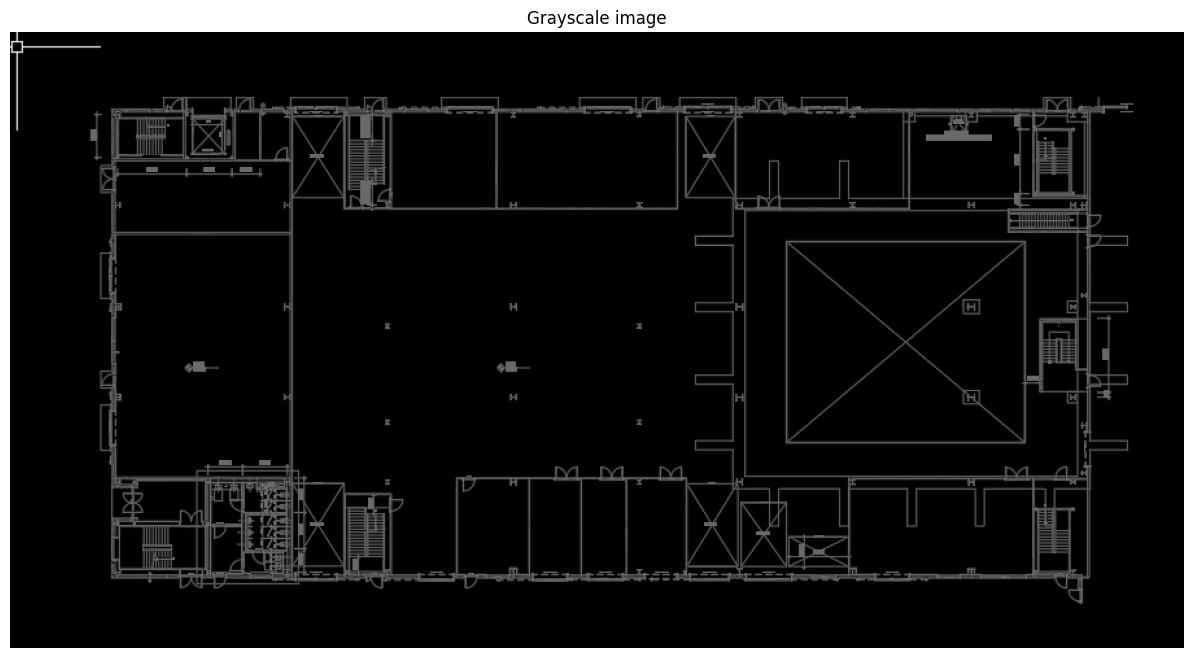

Grayscale min=39, max=252, mean=45.62


In [4]:
import cv2
import numpy as np

bgr_image = cv2.imread(str(image_path))
if bgr_image is None:
    raise RuntimeError(f"OpenCV could not open: {image_path}")

gray_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(16, 8))
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale image")
plt.axis("off")
plt.show()

print(f"Grayscale min={gray_image.min()}, max={gray_image.max()}, mean={gray_image.mean():.2f}")

## 5. Create a Binary Line Mask

Apply a brightness threshold to isolate the bright structural lines that are likely to represent walls or room boundaries.

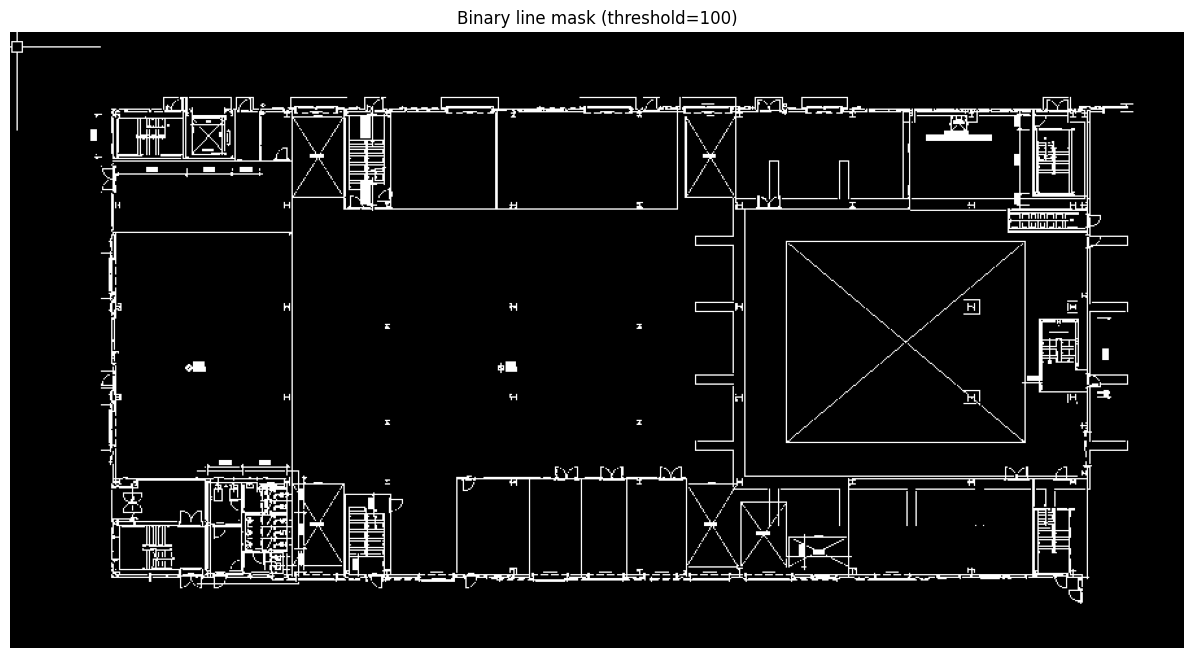

In [5]:
threshold_value = 100
_, binary_line_mask = cv2.threshold(gray_image, threshold_value, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(16, 8))
plt.imshow(binary_line_mask, cmap="gray")
plt.title(f"Binary line mask (threshold={threshold_value})")
plt.axis("off")
plt.show()

## 6. Refine Walls with Morphological Operations

Use dilation and closing to strengthen broken wall lines and close small gaps that prevent room enclosure detection.

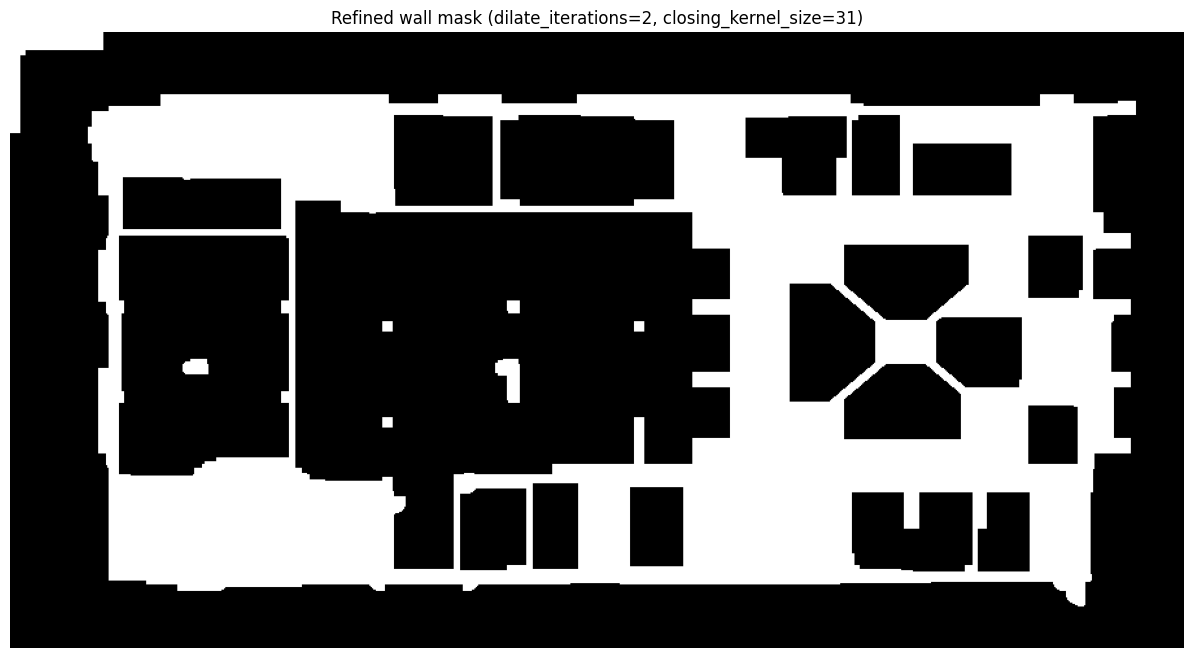

In [6]:
dilate_iterations = 2
closing_kernel_size = 31

refined_walls = cv2.dilate(binary_line_mask, np.ones((3, 3), np.uint8), iterations=dilate_iterations)
refined_walls = cv2.morphologyEx(
    refined_walls,
    cv2.MORPH_CLOSE,
    np.ones((closing_kernel_size, closing_kernel_size), np.uint8),
    iterations=1,
)

plt.figure(figsize=(16, 8))
plt.imshow(refined_walls, cmap="gray")
plt.title(
    f"Refined wall mask (dilate_iterations={dilate_iterations}, closing_kernel_size={closing_kernel_size})"
)
plt.axis("off")
plt.show()

## 7. Invert the Mask and Flood Fill the Background

Invert the wall mask and flood fill from the top-left corner so outside background pixels are separated from enclosed internal regions.

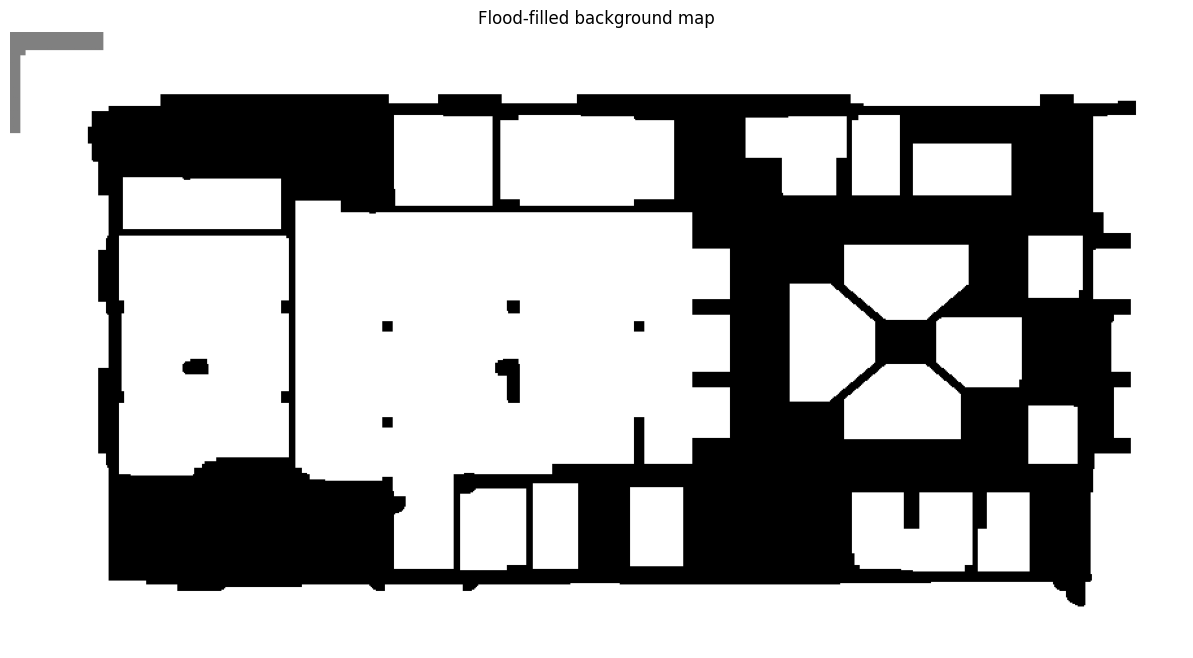

In [7]:
inverted_mask = cv2.bitwise_not(refined_walls)
flood_filled = inverted_mask.copy()
height, width = flood_filled.shape
flood_mask = np.zeros((height + 2, width + 2), np.uint8)
cv2.floodFill(flood_filled, flood_mask, (0, 0), 128)

plt.figure(figsize=(16, 8))
plt.imshow(flood_filled, cmap="gray")
plt.title("Flood-filled background map")
plt.axis("off")
plt.show()

## 8. Extract Enclosed Regions

Keep only the pixels that remain enclosed after flood filling and visualize the result.

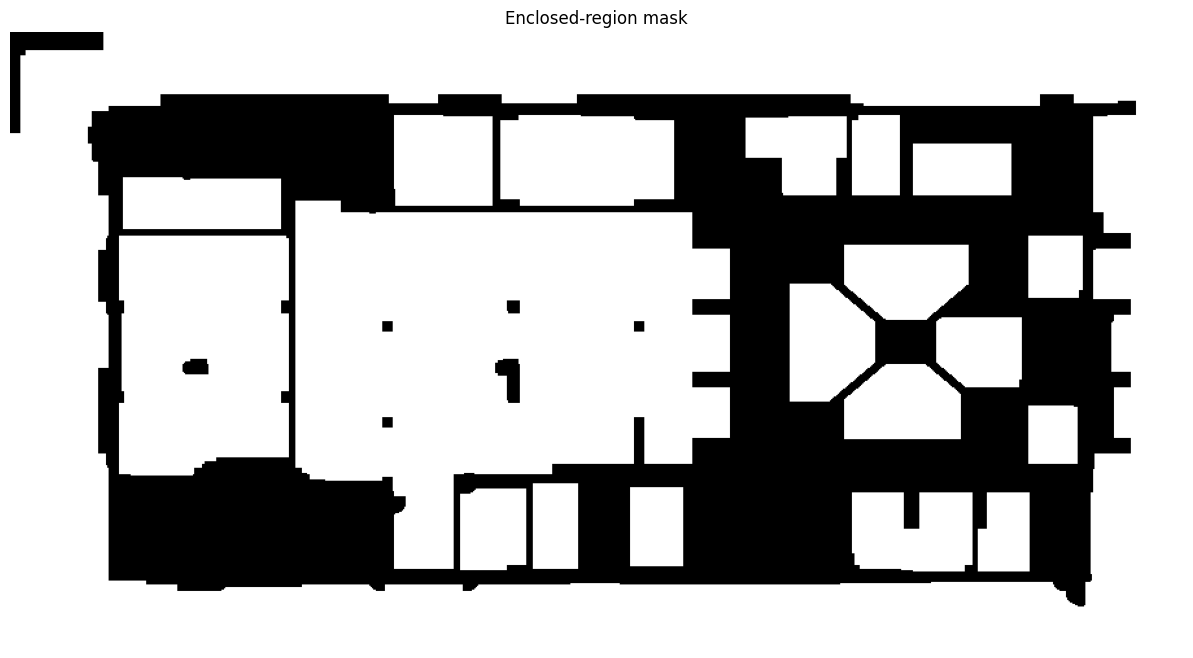

In [8]:
enclosed_regions = np.where(flood_filled == 255, 255, 0).astype(np.uint8)

plt.figure(figsize=(16, 8))
plt.imshow(enclosed_regions, cmap="gray")
plt.title("Enclosed-region mask")
plt.axis("off")
plt.show()

## 9. Measure Connected Components

Measure each enclosed connected component and print bounding box, area, and extent values.

In [9]:
component_count, component_labels, component_stats, component_centroids = cv2.connectedComponentsWithStats(
    enclosed_regions,
    connectivity=8,
)

component_rows = []
for component_id in range(1, component_count):
    x, y, w_box, h_box, area = component_stats[component_id]
    extent = area / float(max(w_box * h_box, 1))
    component_rows.append({
        "component_id": int(component_id),
        "x": int(x),
        "y": int(y),
        "width": int(w_box),
        "height": int(h_box),
        "area": int(area),
        "extent": round(extent, 3),
    })

print(f"Connected components (excluding background): {component_count - 1}")
for row in sorted(component_rows, key=lambda item: item["area"], reverse=True):
    print(row)

Connected components (excluding background): 20
{'component_id': 1, 'x': 0, 'y': 0, 'width': 905, 'height': 475, 'area': 138954, 'extent': np.float64(0.323)}
{'component_id': 8, 'x': 220, 'y': 130, 'width': 335, 'height': 284, 'area': 67293, 'extent': np.float64(0.707)}
{'component_id': 9, 'x': 84, 'y': 157, 'width': 131, 'height': 185, 'area': 22756, 'extent': np.float64(0.939)}
{'component_id': 3, 'x': 378, 'y': 64, 'width': 134, 'height': 70, 'area': 8930, 'extent': np.float64(0.952)}
{'component_id': 2, 'x': 296, 'y': 64, 'width': 76, 'height': 70, 'area': 5269, 'extent': np.float64(0.99)}
{'component_id': 19, 'x': 649, 'y': 355, 'width': 93, 'height': 61, 'area': 5186, 'extent': np.float64(0.914)}
{'component_id': 12, 'x': 601, 'y': 194, 'width': 66, 'height': 91, 'area': 4950, 'extent': np.float64(0.824)}
{'component_id': 7, 'x': 87, 'y': 112, 'width': 122, 'height': 40, 'area': 4799, 'extent': np.float64(0.983)}
{'component_id': 11, 'x': 643, 'y': 164, 'width': 96, 'height': 58,

## 10. Filter Candidate Rooms

Filter components using size, border-touch, and shape heuristics. For each retained candidate, compute a simple four-point rectangle and report basic metrics.

In [10]:
min_room_area = 1700
max_room_area = 90000
min_extent = 0.68

image_height, image_width = enclosed_regions.shape
room_candidates = []

for component_id in range(1, component_count):
    x, y, w_box, h_box, area = component_stats[component_id]
    touches_border = x == 0 or y == 0 or x + w_box >= image_width or y + h_box >= image_height
    extent = area / float(max(w_box * h_box, 1))

    if touches_border:
        continue
    if area < min_room_area or area > max_room_area:
        continue
    if extent < min_extent:
        continue

    component_mask = (component_labels == component_id).astype(np.uint8) * 255
    contours, _ = cv2.findContours(component_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour = max(contours, key=cv2.contourArea)
    rect = cv2.minAreaRect(contour)
    box = cv2.boxPoints(rect).astype(int)
    line_density = float(binary_line_mask[component_mask > 0].mean() / 255.0)

    room_candidates.append({
        "component_id": int(component_id),
        "area": int(area),
        "bbox": [int(x), int(y), int(w_box), int(h_box)],
        "extent": round(extent, 3),
        "line_density": round(line_density, 4),
        "points": [[int(px), int(py)] for px, py in box.tolist()],
    })

room_candidates = sorted(room_candidates, key=lambda item: item["area"], reverse=True)
room_count = len(room_candidates)

print(f"Retained room candidates: {room_count}")
for index, candidate in enumerate(room_candidates, start=1):
    print(f"Room {index:02d}: {candidate}")

Retained room candidates: 19
Room 01: {'component_id': 8, 'area': 67293, 'bbox': [220, 130, 335, 284], 'extent': np.float64(0.707), 'line_density': 0.0, 'points': [[554, 413], [220, 413], [220, 130], [554, 130]]}
Room 02: {'component_id': 9, 'area': 22756, 'bbox': [84, 157, 131, 185], 'extent': np.float64(0.939), 'line_density': 0.0, 'points': [[213, 340], [83, 340], [83, 157], [213, 157]]}
Room 03: {'component_id': 3, 'area': 8930, 'bbox': [378, 64, 134, 70], 'extent': np.float64(0.952), 'line_density': 0.0, 'points': [[511, 133], [378, 133], [378, 64], [511, 64]]}
Room 04: {'component_id': 2, 'area': 5269, 'bbox': [296, 64, 76, 70], 'extent': np.float64(0.99), 'line_density': 0.0, 'points': [[371, 133], [296, 133], [296, 64], [371, 64]]}
Room 05: {'component_id': 19, 'area': 5186, 'bbox': [649, 355, 93, 61], 'extent': np.float64(0.914), 'line_density': 0.0, 'points': [[740, 414], [648, 414], [648, 354], [740, 354]]}
Room 06: {'component_id': 12, 'area': 4950, 'bbox': [601, 194, 66, 9

## 11. Visualize Bounding Boxes on the Image

Draw green room overlays, four-point rectangles, and labels on the original image. The displayed room count must match the retained candidate list.

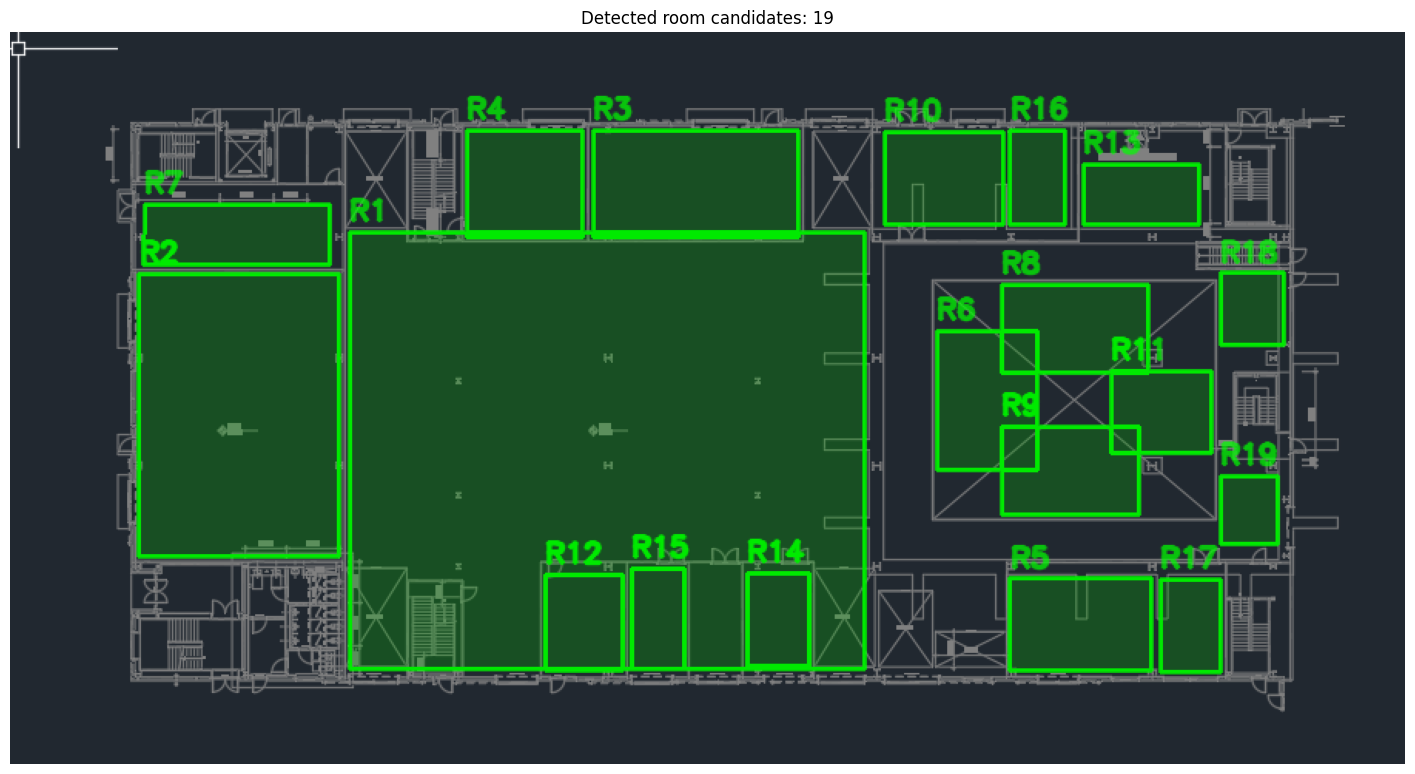

Saved overlay image to: /Users/andy/works/ai/maf-boilerplate/data/original1_room_overlay.png
Room 01 4-point coordinates: [[554, 413], [220, 413], [220, 130], [554, 130]]
Room 02 4-point coordinates: [[213, 340], [83, 340], [83, 157], [213, 157]]
Room 03 4-point coordinates: [[511, 133], [378, 133], [378, 64], [511, 64]]
Room 04 4-point coordinates: [[371, 133], [296, 133], [296, 64], [371, 64]]
Room 05 4-point coordinates: [[740, 414], [648, 414], [648, 354], [740, 354]]
Room 06 4-point coordinates: [[666, 284], [601, 284], [601, 194], [666, 194]]
Room 07 4-point coordinates: [[207, 151], [86, 151], [87, 112], [207, 112]]
Room 08 4-point coordinates: [[738, 221], [643, 221], [643, 164], [738, 164]]
Room 09 4-point coordinates: [[732, 313], [643, 313], [643, 256], [732, 256]]
Room 10 4-point coordinates: [[644, 125], [567, 125], [567, 65], [644, 65]]
Room 11 4-point coordinates: [[779, 273], [714, 273], [714, 220], [779, 220]]
Room 12 4-point coordinates: [[397, 414], [347, 414], [347,

In [12]:
overlay_bgr = bgr_image.copy()
fill_bgr = bgr_image.copy()

for index, candidate in enumerate(room_candidates, start=1):
    polygon = np.array(candidate["points"], dtype=np.int32)
    cv2.fillPoly(fill_bgr, [polygon], color=(0, 180, 0))
    cv2.polylines(overlay_bgr, [polygon], isClosed=True, color=(0, 255, 0), thickness=2)
    label_x, label_y = candidate["bbox"][0], max(candidate["bbox"][1] - 8, 20)
    cv2.putText(
        overlay_bgr,
        f"R{index}",
        (label_x, label_y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2,
        cv2.LINE_AA,
    )

annotated_bgr = cv2.addWeighted(fill_bgr, 0.28, overlay_bgr, 0.72, 0.0)
annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)
output_path = image_path.parent / "original1_room_overlay.png"
cv2.imwrite(str(output_path), annotated_bgr)

plt.figure(figsize=(18, 10))
plt.imshow(annotated_rgb)
plt.title(f"Detected room candidates: {room_count}")
plt.axis("off")
plt.show()

print(f"Saved overlay image to: {output_path}")
for index, candidate in enumerate(room_candidates, start=1):
    print(f"Room {index:02d} 4-point coordinates: {candidate['points']}")

## 12. Tune Threshold and Morphology Parameters

Rerun the enclosure pipeline for several threshold and morphology settings so segmentation quality can be compared quickly.

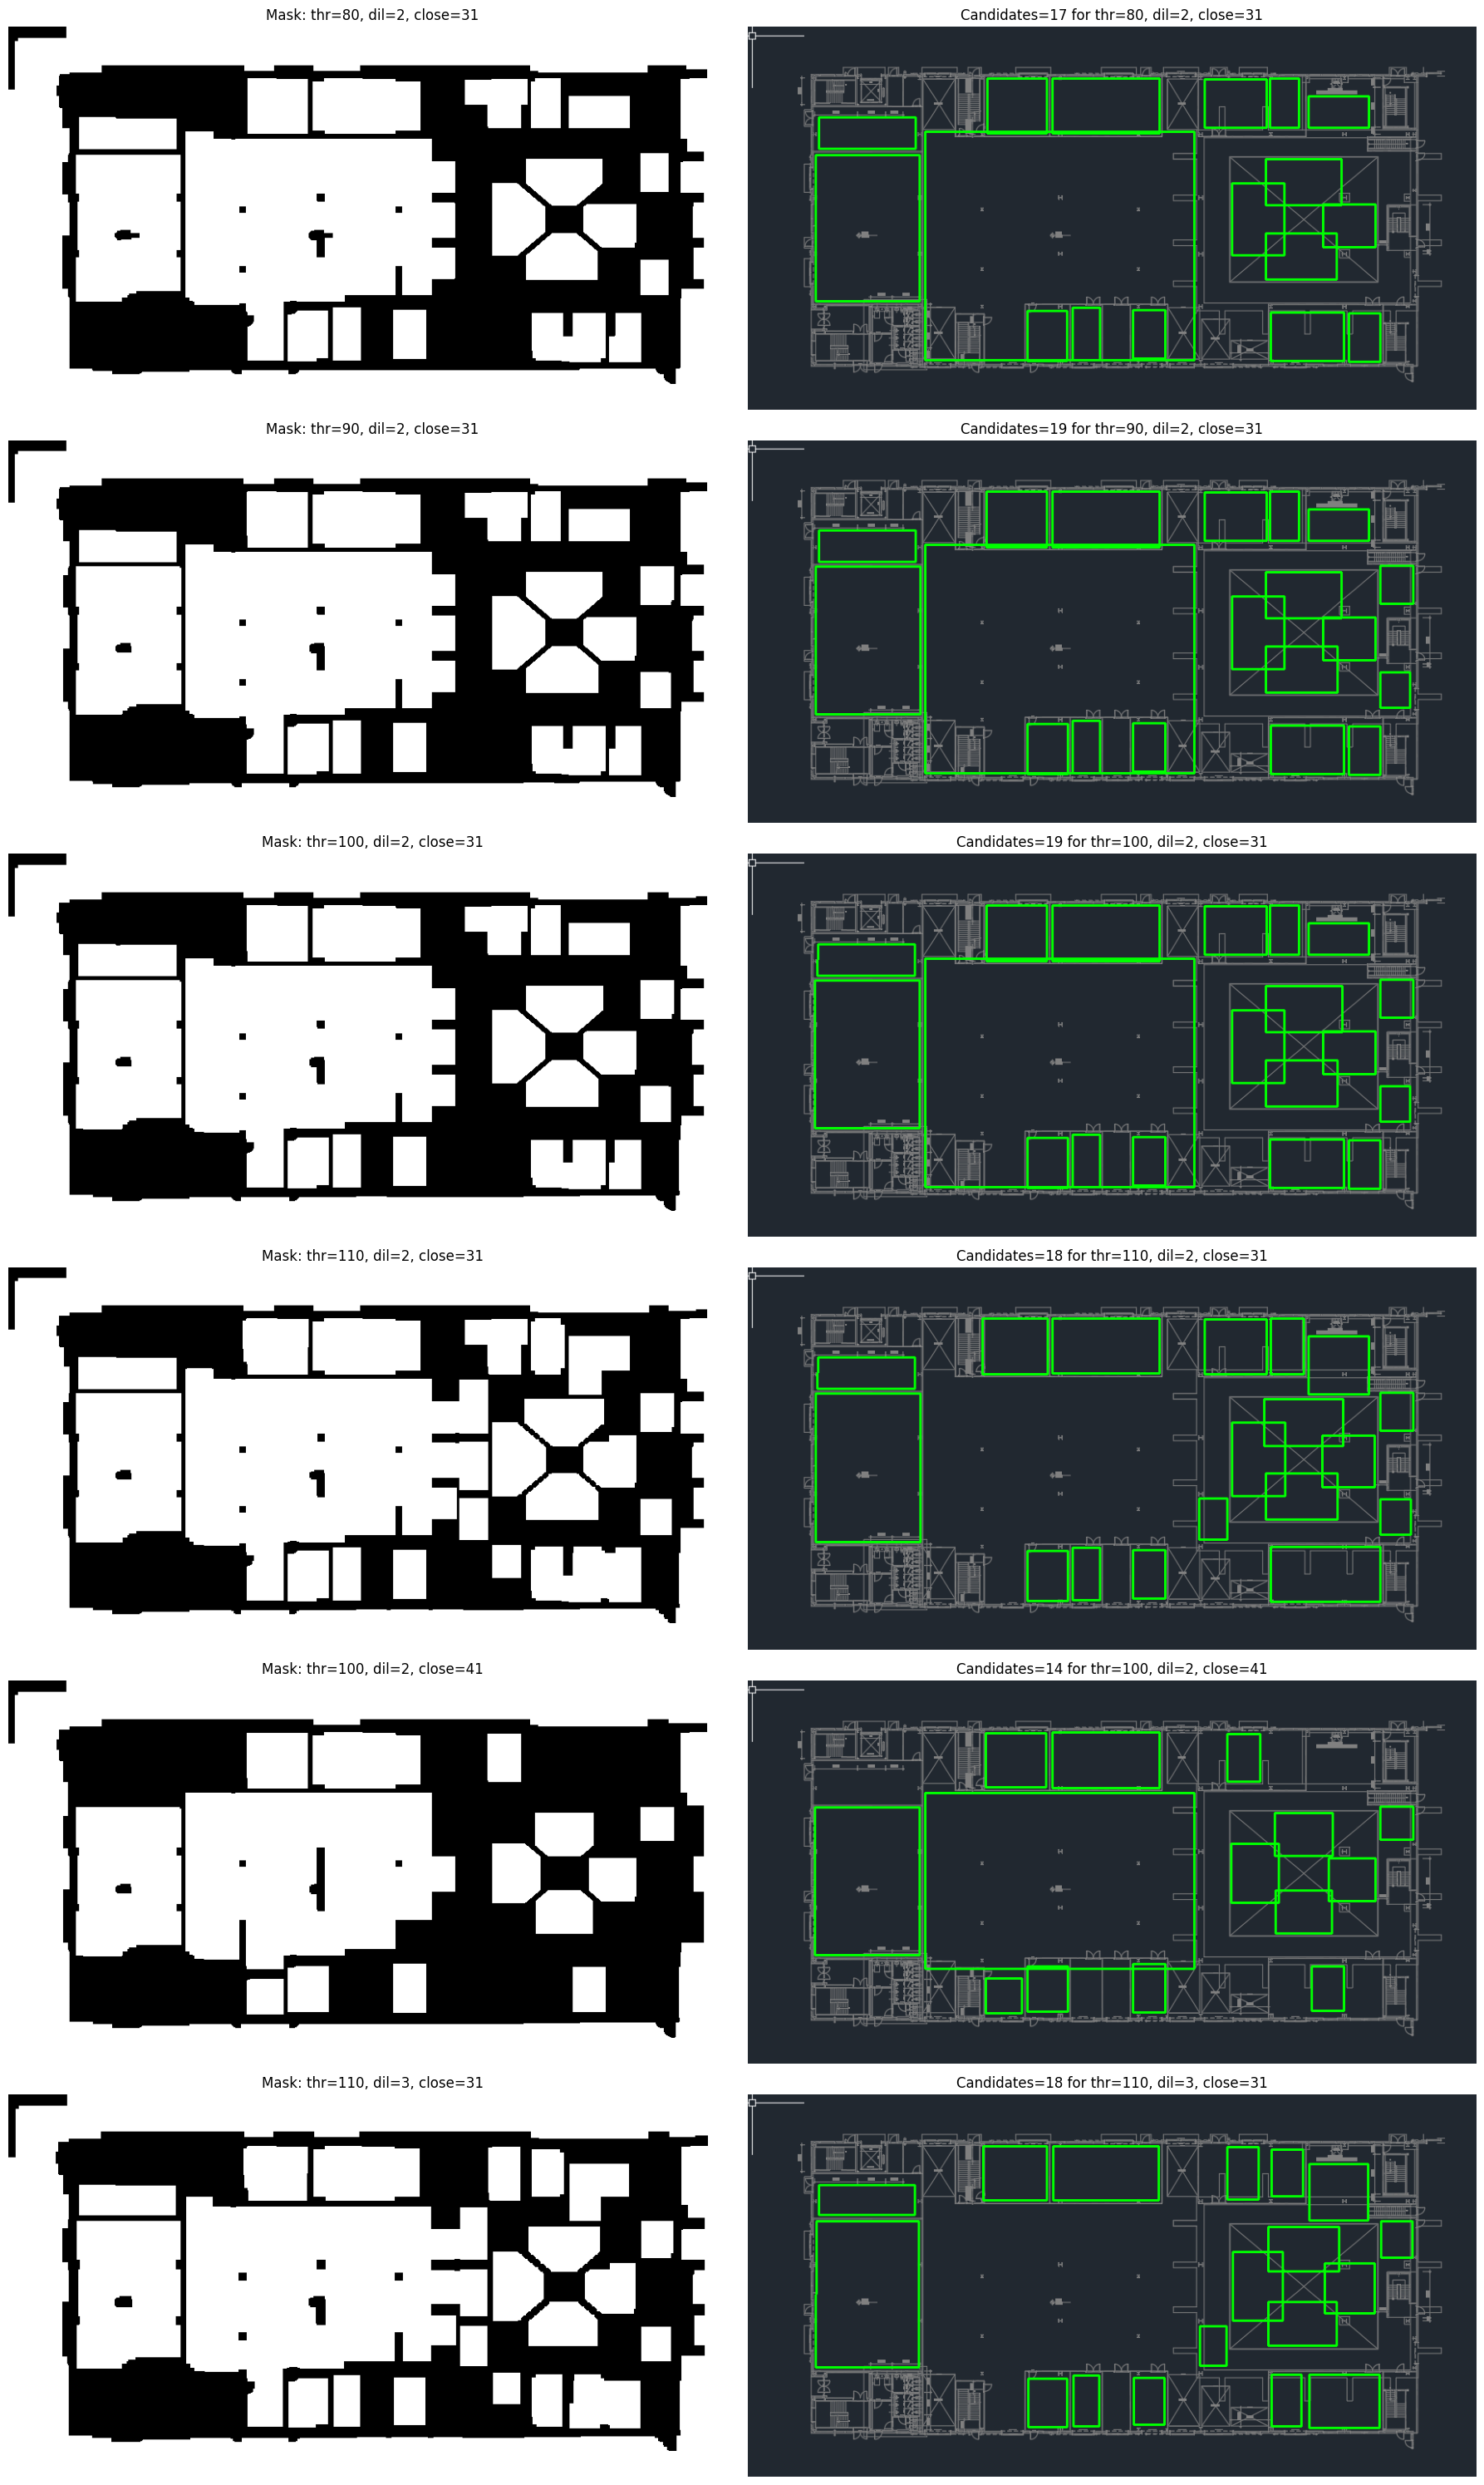

In [13]:
def run_room_pipeline(gray, threshold_value, dilate_iterations, closing_kernel_size, min_room_area=1700, max_room_area=90000, min_extent=0.68):
    _, line_mask = cv2.threshold(gray, threshold_value, 255, cv2.THRESH_BINARY)
    refined = cv2.dilate(line_mask, np.ones((3, 3), np.uint8), iterations=dilate_iterations)
    refined = cv2.morphologyEx(
        refined,
        cv2.MORPH_CLOSE,
        np.ones((closing_kernel_size, closing_kernel_size), np.uint8),
        iterations=1,
    )

    free = cv2.bitwise_not(refined)
    flood = free.copy()
    h, w = flood.shape
    mask = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(flood, mask, (0, 0), 128)
    enclosed = np.where(flood == 255, 255, 0).astype(np.uint8)

    component_count, component_labels, component_stats, _ = cv2.connectedComponentsWithStats(enclosed, connectivity=8)
    rooms = []
    for component_id in range(1, component_count):
        x, y, w_box, h_box, area = component_stats[component_id]
        extent = area / float(max(w_box * h_box, 1))
        touches_border = x == 0 or y == 0 or x + w_box >= w or y + h_box >= h
        if touches_border or area < min_room_area or area > max_room_area or extent < min_extent:
            continue
        component_mask = (component_labels == component_id).astype(np.uint8) * 255
        contours, _ = cv2.findContours(component_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contour = max(contours, key=cv2.contourArea)
        rect = cv2.minAreaRect(contour)
        box = cv2.boxPoints(rect).astype(int)
        rooms.append({
            "component_id": int(component_id),
            "area": int(area),
            "bbox": [int(x), int(y), int(w_box), int(h_box)],
            "extent": round(extent, 3),
            "points": [[int(px), int(py)] for px, py in box.tolist()],
        })

    return {
        "line_mask": line_mask,
        "refined_walls": refined,
        "enclosed": enclosed,
        "rooms": sorted(rooms, key=lambda item: item["area"], reverse=True),
    }


tuning_settings = [
    (80, 2, 31),
    (90, 2, 31),
    (100, 2, 31),
    (110, 2, 31),
    (100, 2, 41),
    (110, 3, 31),
]

fig, axes = plt.subplots(len(tuning_settings), 2, figsize=(18, 5 * len(tuning_settings)))

for row_index, (thr_value, dil_value, close_value) in enumerate(tuning_settings):
    result = run_room_pipeline(gray_image, thr_value, dil_value, close_value)
    preview_rgb = cv2.cvtColor(bgr_image.copy(), cv2.COLOR_BGR2RGB)

    for candidate in result["rooms"]:
        polygon = np.array(candidate["points"], dtype=np.int32)
        cv2.polylines(preview_rgb, [polygon], isClosed=True, color=(0, 255, 0), thickness=2)

    axes[row_index, 0].imshow(result["enclosed"], cmap="gray")
    axes[row_index, 0].set_title(
        f"Mask: thr={thr_value}, dil={dil_value}, close={close_value}"
    )
    axes[row_index, 0].axis("off")

    axes[row_index, 1].imshow(preview_rgb)
    axes[row_index, 1].set_title(
        f"Candidates={len(result['rooms'])} for thr={thr_value}, dil={dil_value}, close={close_value}"
    )
    axes[row_index, 1].axis("off")

plt.tight_layout()
plt.show()